In [ ]:
%matplotlib inline

ndevices = 30
import os
os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={ndevices}"
os.environ["OMP_NUM_THREADS"] = f"{ndevices}"
os.environ["MKL_NUM_THREADS"] = f"{ndevices}"
os.environ["NUMEXPR_NUM_THREADS"] = f"{ndevices}"
os.environ["OPENBLAS_NUM_THREADS"] = f"{ndevices}"
os.environ["VECLIB_MAXIMUM_THREADS"] = f"{ndevices}"
os.environ["NUMBA_NUM_THREADS"] = f"{ndevices}"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"

import multiprocessing
import pandas as pd
import sys
import glob
from functools import partial
from astropy.io import fits, ascii
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table
from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value, wCDM, LambdaCDM
import scipy.stats as st
from scipy.optimize import minimize
from scipy.signal import fftconvolve
import warnings
import h5py
import emcee
import corner
from scipy import stats
import time
plt.style.use('style.mplstyle')

In [ ]:
bands = ['u', 'g', 'r', 'i', 'z']#, 'y']
bands_idx = {b: i for i, b in enumerate(bands)}

def read_quasars_from_hdf5(file_path):
    quasar_list = []
    with h5py.File(file_path, "r") as hdf:
        for group_name in hdf.keys():
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            quasar_list.append(quasar)
    return quasar_list

hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

def populate_sdss_fields(d):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        print(f"Warning: {d['sdss_name']} not found in SDSS data")
        return d
    i = i[0]
    if np.any(fits_data_2['PSFFLUX'][i,:] <= 0):
        return d
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        d['apparent_mag_z'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,4]) + 22.5
        d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 22.5
        d['apparent_mag_r'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,2]) + 22.5
        d['apparent_mag_g'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,1]) + 22.5
        d['apparent_mag_u'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,0]) + 22.5
        d['apparent_mag_z_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,4])/fits_data_2['PSFFLUX'][i,4]
        d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
        d['apparent_mag_r_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,2])/fits_data_2['PSFFLUX'][i,2]
        d['apparent_mag_g_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,1])/fits_data_2['PSFFLUX'][i,1]
        d['apparent_mag_u_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,0])/fits_data_2['PSFFLUX'][i,0]
        d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
        d['conti_fit'] = fits_data['CONTI_FIT'][i]
        d['conti_fit_err'] = fits_data['CONTI_FIT_ERR'][i]
    if any(issubclass(warning.category, RuntimeWarning) for warning in w):
        print(f"RuntimeWarning occurred for {d['sdss_name']}")
        print(fits_data_2['PSFFLUX'][i,:])
        print(w)
    return d

#quasar_list = read_quasars_from_hdf5("data/may12_objs_tauwavelength_taublr_redbands_ds4_merged.h5")
quasar_list = read_quasars_from_hdf5("data/may13_objs_tauwavelength_taublr_freebreak_merged.h5")

print("Number of quasars loaded:", len(quasar_list))

filtered_quasar_list = []
for q in quasar_list:
    accept = True    
    for i, b in enumerate(q['clean_bands']):
        if len(q['magerrs'][b]) == 0:
            continue
        if not ((10**q[f'log_sigma_band'][bands_idx[b]])**2 > 1*(np.nanmean(q['magerrs'][b])**2 + (10**q[f'log_jitter'][i])**2)):
            accept = False

    populate_sdss_fields(q)
    #calc_lam_RF(q)
    #q['delta_time'] = q['times']['r'].max() - q['times']['r'].min()
    if True:
        filtered_quasar_list.append(q)


df = pd.DataFrame(filtered_quasar_list)
#df = df.set_index('object_id')
#df = df.drop(columns=['log_jitter', 'magerrs_mean', 'log_sigma_band', 'log_sigma_band_err', 'clean_bands'])
df = df.drop(columns=['mags', 'times', 'magerrs'])

df_all = df.copy()

# Remove infinite values from numeric columns
columns_with_nans = df.columns[df.isna().any()].tolist()
print("Columns with NaNs:", columns_with_nans)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].where(~np.isinf(df[numeric_cols]), np.nan)
df = df.dropna()

# data cuts
# df = df[df['log_sigma_UV'] < 0]
# df = df[df['log_tau_UV_RF'] > 1]
# df = df[df['log_lbol'] > 44]
# df = df[df['log_mbh'] > 1]
# df = df[df['apparent_mag_i'] < 30]
# #df = df[df['M_i'] > -27]
df = df[df['ebv'] < 0.05]

num_quasars_z_0_1 = len(df[(df['z'] > 0) & (df['z'] <= 1)])
num_quasars_z_gt_3 = len(df[df['z'] > 3])

print("Number of quasars with 0 < z <= 1:", num_quasars_z_0_1)
print("Number of quasars with z > 3:", num_quasars_z_gt_3)
print("Final number of quasars:", len(df))
df.head()

Number of quasars loaded: 1479
Columns with NaNs: []
Number of quasars with 0 < z <= 1: 350
Number of quasars with z > 3: 81
Final number of quasars: 1479


,object_id,clean_bands,dec,eta_A1,eta_A1_err,eta_A2,eta_A2_err,eta_tau1,eta_tau1_err,eta_tau2,...,apparent_mag_g,apparent_mag_u,apparent_mag_z_err,apparent_mag_i_err,apparent_mag_r_err,apparent_mag_g_err,apparent_mag_u_err,color,conti_fit,conti_fit_err
0,1385049,"[u, g, r, i, z]",-0.708190,0.829436,0.058761,0.801089,0.111452,0.022554,0.094835,-0.436581,...,19.665806,19.744036,0.056119,0.024710,0.017769,0.030145,0.034751,0.393955,"[8.885831841895644, -2.931866041161698, 0.0034...","[0.0733176558615467, 0.1169531296595525, 0.000..."
1,1387470,"[u, g, r, i, z]",-0.175792,0.964604,0.077742,1.042578,0.088084,0.154766,0.074410,-0.362260,...,19.834627,19.929401,0.075555,0.040357,0.029988,0.023662,0.034297,0.243955,"[6.817993267233179, -3.5558362633374907, 0.004...","[0.1490556603682158, 0.0940263205119056, 0.000..."
2,1387735,"[u, g, r, i, z]",-0.676568,0.747824,0.075055,0.751545,0.100375,-0.017953,0.041485,-0.516309,...,19.714458,19.952137,0.055411,0.024917,0.018819,0.035953,0.034929,0.306561,"[10.675476275277925, -2.968064709883916, 0.003...","[0.0763972531150098, 0.1340878610203082, 0.000..."
3,1387875,"[u, g, r, i, z]",-0.851407,0.838809,0.071501,0.939608,0.128011,-0.017657,0.098766,-0.423335,...,20.507414,20.407162,0.093236,0.028000,0.024979,0.038794,0.052243,0.379419,"[3.992094064578251, -2.634971846203413, 0.0009...","[0.0509565432738368, 0.303458882758197, 0.0003..."
4,1388307,"[u, g, r, i, z]",0.812130,1.022318,0.081596,1.254194,0.106482,0.013433,0.078658,-0.319234,...,22.286879,22.765182,0.221938,0.060202,0.079553,0.087107,0.284784,1.546286,"[2.1501183338735586, 0.3496334251209383, -0.00...","[0.0720056894523299, 1.5351115468781318, 0.001..."


In [29]:

import numpy as np
from scipy.stats import linregress

def compute_alpha_nu(d):
    lambda0 = 3000.0
    lambda_grid = np.linspace(1000, 3500, 1000)

    # Unpack parameters and errors
    PL_norm, PL_slope, POLY_a, POLY_b, POLY_c = d['conti_fit']
    PL_norm_err, PL_slope_err, POLY_a_err, POLY_b_err, POLY_c_err = d['conti_fit_err']

    # Define internal alpha_nu calculator
    def get_alpha_nu(params):
        a0, slope, a, b, c = params
        lam = lambda_grid
        f_pl = a0 * (lam / lambda0) ** slope
        f_poly = a * (lam - lambda0) + b * (lam - lambda0)**2 + c * (lam - lambda0)**3
        f_conti = f_pl + f_poly

        valid = f_conti > 0
        lam = lam[valid]
        f_conti = f_conti[valid]
        if len(f_conti) < 10:
            return np.nan  # insufficient valid points

        log_lambda = np.log10(lam)
        log_flux = np.log10(f_conti)
        slope_fit, *_ = linregress(log_lambda, log_flux)
        return -(slope_fit + 2)

    # Central value
    central_params = [PL_norm, PL_slope, POLY_a, POLY_b, POLY_c]
    alpha_nu = get_alpha_nu(central_params)

    # Partial derivatives via finite differences
    deltas = [PL_norm_err, PL_slope_err, POLY_a_err, POLY_b_err, POLY_c_err]
    partials = []
    for i in range(5):
        params_up = central_params.copy()
        params_down = central_params.copy()
        params_up[i] += deltas[i]
        params_down[i] -= deltas[i]

        alpha_up = get_alpha_nu(params_up)
        alpha_down = get_alpha_nu(params_down)

        # Check for invalid results before computing derivative
        if not np.isfinite(alpha_up) or not np.isfinite(alpha_down) or deltas[i] == 0:
            return {**d, 'alpha_nu': alpha_nu, 'alpha_nu_err': np.nan}
        else:
            partial = (alpha_up - alpha_down) / (2 * deltas[i])
            partials.append(partial)

    # Error propagation
    alpha_nu_err = np.sqrt(np.sum((np.array(partials) * np.array(deltas))**2))

    # Store in dictionary
    d['alpha_nu'] = alpha_nu
    d['alpha_nu_err'] = alpha_nu_err
    return d

df = df.apply(compute_alpha_nu, axis=1)
df = df.dropna(subset=['alpha_nu', 'alpha_nu_err'])


ImportError: Missing optional dependency 'pytables'.  Use pip or conda to install pytables.

/tmp/ipykernel_2075258/933430729.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


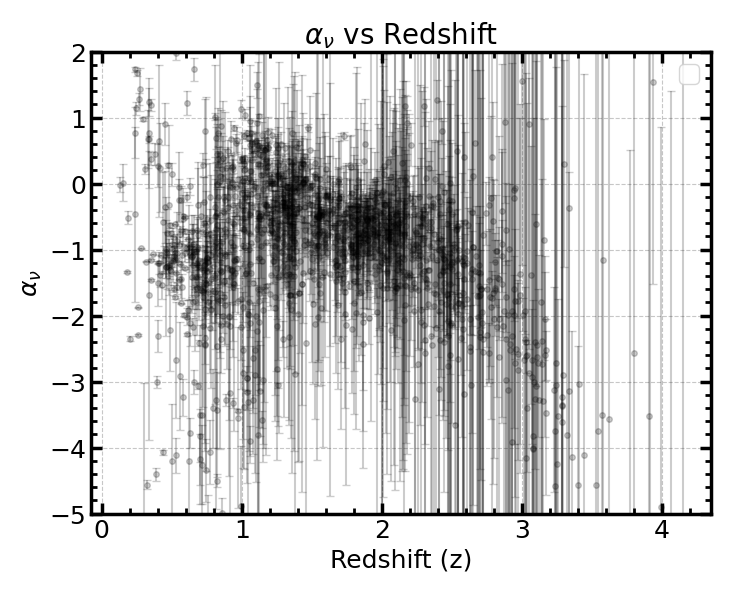

In [33]:
plt.figure(figsize=(8, 6))
plt.errorbar(df['z'], df['alpha_nu'], yerr=df['alpha_nu_err'], fmt='o', markersize=4, capsize=3, lw=1.5,alpha=0.2, color='black')
#plt.axhline(-0.5, color='red', linestyle='--', label='y = -0.5')
plt.xlabel('Redshift (z)')
plt.ylabel(r'$\alpha_{\nu}$')
plt.title(r'$\alpha_{\nu}$ vs Redshift')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-5, 2)
plt.legend()
plt.show()